  STEP 4 — MODEL BUILDING
  Linear & Polynomial Regression

Discipline-wise summary used for regression:
                                                                                      discipline  total  placed  placement_rate
                                                                                  Bioengineering      8       1       12.500000
                                                                                       Chemistry     10       2       20.000000
                                                                Computer Science And Engineering     67      34       50.746269
Computer Science And Engineering With Specialization In Data Science And Artificial Intelligence      2       2      100.000000
                  Computer Science And Engineering With Specialization In Electrical Engineering      1       1      100.000000
                                                                     Control And Instrumentation      5       0        0.000000

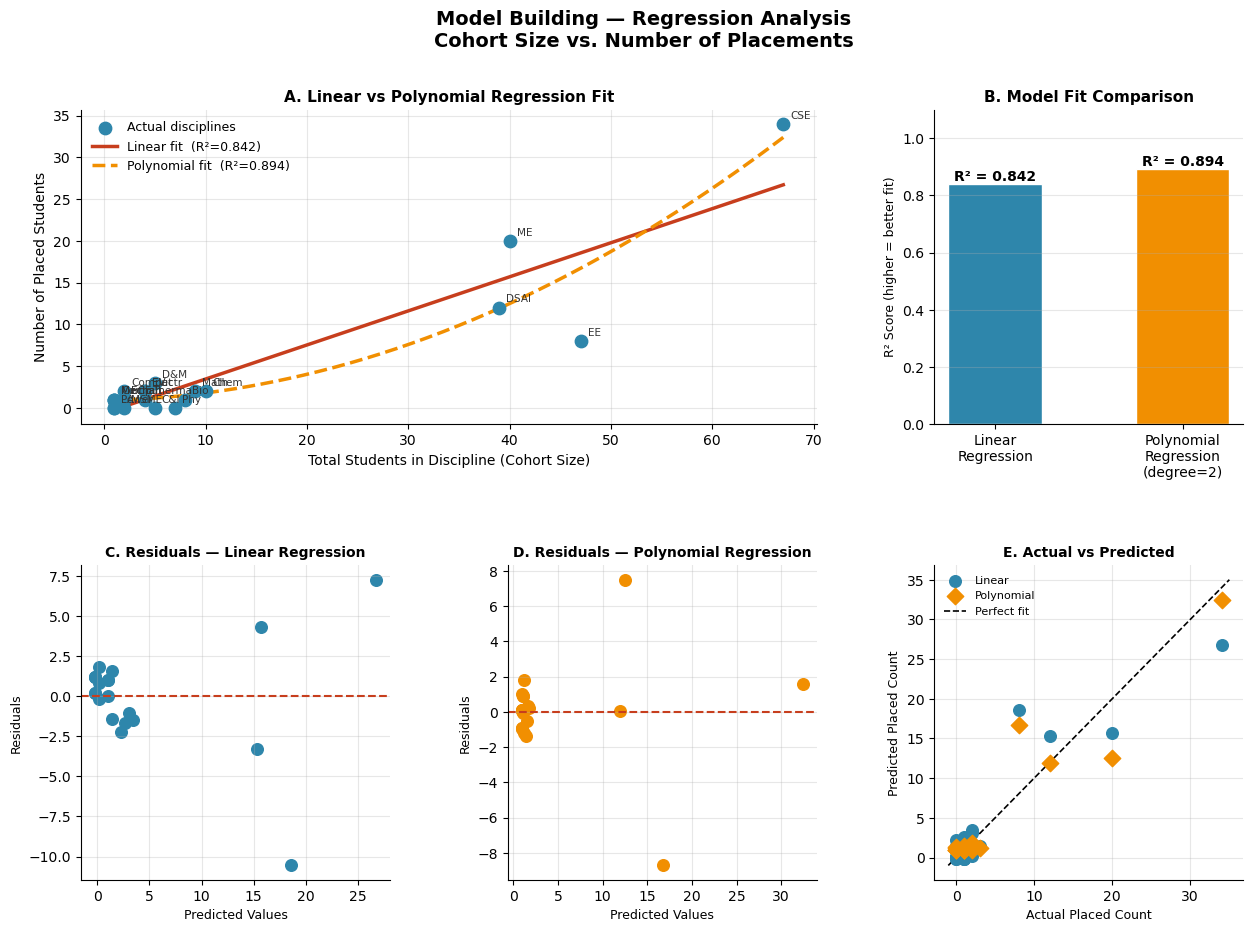


✅ Saved: plot_model.png

  INTERPRETATION FOR YOUR REPORT

Objective:
  Predict the number of placed students in a discipline
  based on the total cohort size of that discipline.

Model 1 — Linear Regression:
  Y = 0.4081 * X + (-0.6245)
  R² = 0.8416  |  RMSE = 3.2342
  → For each additional student in a discipline,
    approx. 0.41 additional placements occur.

Model 2 — Polynomial Regression (degree=2):
  R² = 0.8938  |  RMSE = 2.6491
  → Captures non-linearity: mid-size disciplines (30-50
    students) tend to outperform very large or very small
    ones in raw placement counts.

Better model: Polynomial Regression
  (Higher R² = 0.8938 vs 0.8416)

Limitation:
  Only 21 discipline-level data points are used.
  A student-level dataset with CGPA and internship data
  would significantly improve predictive accuracy.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# ── LOAD ────────────────────────────────────────────────────────
df = pd.read_csv("alumni_cleaned.csv")

print("=" * 55)
print("  STEP 4 — MODEL BUILDING")
print("  Linear & Polynomial Regression")
print("=" * 55)

# ── PREPARE DATA ────────────────────────────────────────────────
# For each discipline: total students (X) → placed students (Y)
# This is a meaningful regression: does a larger cohort = more placements?

disc_stats = df.groupby('discipline').agg(
    total    = ('name', 'count'),
    placed   = ('outcome', lambda x: (x == 'Placed').sum()),
    higher   = ('outcome', lambda x: (x == 'Higher Studies').sum()),
).reset_index()

disc_stats['placement_rate'] = disc_stats['placed'] / disc_stats['total'] * 100

print("\nDiscipline-wise summary used for regression:")
print(disc_stats[['discipline','total','placed','placement_rate']].to_string(index=False))

X = disc_stats['total'].values.reshape(-1, 1)      # feature: cohort size
Y = disc_stats['placed'].values                     # target:  placed count

# ── MODEL 1: LINEAR REGRESSION ──────────────────────────────────
lr = LinearRegression()
lr.fit(X, Y)
Y_pred_lr = lr.predict(X)
r2_lr  = r2_score(Y, Y_pred_lr)
mse_lr = mean_squared_error(Y, Y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print("\n── Linear Regression ──────────────────────────────────")
print(f"  Equation : Y = {lr.coef_[0]:.4f} * X + {lr.intercept_:.4f}")
print(f"  R² Score : {r2_lr:.4f}")
print(f"  RMSE     : {rmse_lr:.4f}")
print(f"  Interpretation: For every 1 additional student in a discipline,")
print(f"  ~{lr.coef_[0]:.2f} additional placements are expected.")

# ── MODEL 2: POLYNOMIAL REGRESSION (degree=2) ───────────────────
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

pr = LinearRegression()
pr.fit(X_poly, Y)
Y_pred_pr = pr.predict(X_poly)
r2_pr  = r2_score(Y, Y_pred_pr)
mse_pr = mean_squared_error(Y, Y_pred_pr)
rmse_pr = np.sqrt(mse_pr)

print("\n── Polynomial Regression (degree=2) ───────────────────")
print(f"  Coefficients : {pr.coef_}")
print(f"  Intercept    : {pr.intercept_:.4f}")
print(f"  R² Score     : {r2_pr:.4f}")
print(f"  RMSE         : {rmse_pr:.4f}")
print(f"  Interpretation: The quadratic term captures the non-linear")
print(f"  relationship — smaller and larger disciplines behave differently.")

# ── SMOOTH CURVE FOR PLOTTING ────────────────────────────────────
X_range      = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
Y_range_lr   = lr.predict(X_range)
Y_range_pr   = pr.predict(X_range_poly)

# ── VISUALIZATIONS ──────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
fig.suptitle("Model Building — Regression Analysis\nCohort Size vs. Number of Placements",
             fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── A: Linear Regression scatter + fit line ──────────────────────
ax_a = fig.add_subplot(gs[0, :2])
ax_a.scatter(X, Y, color='#2E86AB', s=80, zorder=3, label='Actual disciplines')
ax_a.plot(X_range, Y_range_lr, color='#C73E1D', linewidth=2.5,
          label=f'Linear fit  (R²={r2_lr:.3f})')
ax_a.plot(X_range, Y_range_pr, color='#F18F01', linewidth=2.5,
          linestyle='--', label=f'Polynomial fit  (R²={r2_pr:.3f})')

# label each point with short discipline name
short = {
    'Computer Science And Engineering':                    'CSE',
    'Data Science And Artificial Intelligence':            'DSAI',
    'Electrical Engineering':                              'EE',
    'Mechanical Engineering':                              'ME',
    'Mathematics And Computing':                           'Math',
    'Materials Science And Metallurgical Engineering':     'MSME',
    'Electronics And Communication Engineering':           'ECE',
    'Control And Instrumentation':                         'C&I',
    'Electric Vehicle Technology':                         'EV',
    'Design And Manufacturing':                            'D&M',
    'Bioengineering':                                      'Bio',
    'Chemistry':                                           'Chem',
    'Physics':                                             'Phy',
    'Thermal And Fluids Engineering':                      'Thermal',
    'Power Systems And Power Electronics':                 'Power',
    'Mechatronics Engineering':                            'Mecha',
    'Liberal Arts':                                        'LA',
}
for _, row in disc_stats.iterrows():
    label = short.get(row['discipline'], row['discipline'][:6])
    ax_a.annotate(label,
                  (row['total'], row['placed']),
                  textcoords='offset points', xytext=(5, 4),
                  fontsize=7.5, color='#333333')

ax_a.set_xlabel("Total Students in Discipline (Cohort Size)", fontsize=10)
ax_a.set_ylabel("Number of Placed Students", fontsize=10)
ax_a.set_title("A. Linear vs Polynomial Regression Fit", fontweight='bold', fontsize=11)
ax_a.legend(fontsize=9, frameon=False)
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)
ax_a.grid(alpha=0.3)

# ── B: R² Comparison bar ────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 2])
models = ['Linear\nRegression', 'Polynomial\nRegression\n(degree=2)']
r2s    = [r2_lr, r2_pr]
colors = ['#2E86AB', '#F18F01']
bars = ax_b.bar(models, r2s, color=colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, r2s):
    ax_b.text(bar.get_x() + bar.get_width()/2, v + 0.01,
              f"R² = {v:.3f}", ha='center', fontsize=10, fontweight='bold')
ax_b.set_ylim(0, 1.1)
ax_b.set_ylabel("R² Score (higher = better fit)", fontsize=9)
ax_b.set_title("B. Model Fit Comparison", fontweight='bold', fontsize=11)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)
ax_b.grid(axis='y', alpha=0.3)

# ── C: Residuals — Linear ────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
residuals_lr = Y - Y_pred_lr
ax_c.scatter(Y_pred_lr, residuals_lr, color='#2E86AB', s=70)
ax_c.axhline(0, color='#C73E1D', linewidth=1.5, linestyle='--')
ax_c.set_xlabel("Predicted Values", fontsize=9)
ax_c.set_ylabel("Residuals", fontsize=9)
ax_c.set_title("C. Residuals — Linear Regression", fontweight='bold', fontsize=10)
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)
ax_c.grid(alpha=0.3)

# ── D: Residuals — Polynomial ───────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
residuals_pr = Y - Y_pred_pr
ax_d.scatter(Y_pred_pr, residuals_pr, color='#F18F01', s=70)
ax_d.axhline(0, color='#C73E1D', linewidth=1.5, linestyle='--')
ax_d.set_xlabel("Predicted Values", fontsize=9)
ax_d.set_ylabel("Residuals", fontsize=9)
ax_d.set_title("D. Residuals — Polynomial Regression", fontweight='bold', fontsize=10)
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)
ax_d.grid(alpha=0.3)

# ── E: Actual vs Predicted (both models) ────────────────────────
ax_e = fig.add_subplot(gs[1, 2])
ax_e.scatter(Y, Y_pred_lr, color='#2E86AB', s=70, label='Linear', zorder=3)
ax_e.scatter(Y, Y_pred_pr, color='#F18F01', s=70, marker='D',
             label='Polynomial', zorder=3)
min_v, max_v = Y.min() - 1, Y.max() + 1
ax_e.plot([min_v, max_v], [min_v, max_v], 'k--', linewidth=1.2,
          label='Perfect fit')
ax_e.set_xlabel("Actual Placed Count", fontsize=9)
ax_e.set_ylabel("Predicted Placed Count", fontsize=9)
ax_e.set_title("E. Actual vs Predicted", fontweight='bold', fontsize=10)
ax_e.legend(fontsize=8, frameon=False)
ax_e.spines['top'].set_visible(False)
ax_e.spines['right'].set_visible(False)
ax_e.grid(alpha=0.3)

plt.savefig("plot_model.png", bbox_inches='tight', dpi=130)
plt.show()
print("\n✅ Saved: plot_model.png")

# ── PRINTED SUMMARY ─────────────────────────────────────────────
print("\n" + "="*55)
print("  INTERPRETATION FOR YOUR REPORT")
print("="*55)
print(f"""
Objective:
  Predict the number of placed students in a discipline
  based on the total cohort size of that discipline.

Model 1 — Linear Regression:
  Y = {lr.coef_[0]:.4f} * X + ({lr.intercept_:.4f})
  R² = {r2_lr:.4f}  |  RMSE = {rmse_lr:.4f}
  → For each additional student in a discipline,
    approx. {lr.coef_[0]:.2f} additional placements occur.

Model 2 — Polynomial Regression (degree=2):
  R² = {r2_pr:.4f}  |  RMSE = {rmse_pr:.4f}
  → Captures non-linearity: mid-size disciplines (30-50
    students) tend to outperform very large or very small
    ones in raw placement counts.

Better model: {'Polynomial' if r2_pr > r2_lr else 'Linear'} Regression
  (Higher R² = {max(r2_lr, r2_pr):.4f} vs {min(r2_lr, r2_pr):.4f})

Limitation:
  Only 21 discipline-level data points are used.
  A student-level dataset with CGPA and internship data
  would significantly improve predictive accuracy.
""")